In [1]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

#Import own functions
from functions import feature_engineering, label, create_sequences, import_csv

In [2]:
#Import latent ocsvm hybrid model
model_dir = Path("models/saved_hybrid")

ocsvm = joblib.load(model_dir / "hybrid_model.pkl")
ocsvm_scaler = joblib.load(model_dir / "scaler.pkl")
ocsvm_feature_columns = joblib.load(model_dir / "feature_columns.pkl")

print("OCSVM-modellen er lastet inn.")
print("Antall features:", len(ocsvm_feature_columns))

OCSVM-modellen er lastet inn.
Antall features: 18


In [3]:
#import LSTM model to be able to get latent layer 
model_dir = Path("saved_lstm_autoencoder_actual")

model = tf.keras.models.load_model(model_dir / "lstm_autoencoder.keras")

lstm_scaler = joblib.load(model_dir / "scaler.pkl")
threshold = joblib.load(model_dir / "threshold.pkl")
lstm_feature_columns = joblib.load(model_dir / "feature_columns.pkl")
window_size = joblib.load(model_dir / "window_size.pkl")

print("Modellen er lastet inn.")
print("Threshold:", threshold)
print("Window size:", window_size)
print("Antall features:", len(lstm_feature_columns))

Modellen er lastet inn.
Threshold: 0.10404626509857504
Window size: 30
Antall features: 18


In [4]:
#Define CSV's to import and use for testing
attack_csv = [
    "Attack-0.csv",
    "Attack-1.csv"
]

attack_log = [
    "attack-log-02-01-2023.csv"
]

csv_folder = Path.cwd()/"CSV files"

In [5]:
#importing csv's
attack_df = import_csv(attack_csv, csv_folder)
attack_log_df = import_csv(attack_log, csv_folder)

Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Attack-0.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Attack-1.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\attack-log-02-01-2023.csv


In [6]:
#label data
attack_df=label(attack_df,attack_log_df)

In [7]:
#split data
X_eval = feature_engineering(attack_df.drop(columns=["Label"]))
y_eval = attack_df["Label"].astype(int).values
print("X_eval shape:", X_eval.shape, "\ny_eval shape:", y_eval.shape)

X_eval shape: (282077, 18) 
y_eval shape: (282077,)


In [8]:
#scale
X_eval_scaled = lstm_scaler.transform(X_eval)

In [9]:
#create sequences
X_seq,y_seq = create_sequences(X_eval_scaled,window_size, labels=y_eval)

In [10]:
#define encoder model to get latent layer
encoder_model = Model(
    inputs=model.input,
    outputs=model.get_layer("dense").output
)


In [11]:
#Get latent layer from test data
X_eval_latent = encoder_model.predict(X_seq)
print("X_eval_latent shape:", X_eval_latent.shape)

8814/8814 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step
X_eval_latent shape: (282048, 16)


In [12]:
#Scale latent data
X_eval_latent_scaled = ocsvm_scaler.transform(X_eval_latent)

In [13]:
y_pred_raw = ocsvm.predict(X_eval_latent_scaled)
y_pred = (y_pred_raw == -1).astype(int) #change from 1=normal & -1=anomaly to 0=normal and 1=anomaly

In [14]:
print("\nPredicted labels:")
print(pd.Series(y_pred).value_counts())

print("\nTrue labels:")
print(pd.Series(y_seq).value_counts())


Predicted labels:
0    205297
1     76751
Name: count, dtype: int64

True labels:
0    214766
1     67282
Name: count, dtype: int64


In [15]:
print("Confusion matrix:")
print(confusion_matrix(y_seq, y_pred))

print("\nClassification report:")
print(classification_report(
    y_seq,
    y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))

print("Accuracy:", accuracy_score(y_seq, y_pred))
print("Precision:", precision_score(y_seq, y_pred, zero_division=0))
print("Recall:", recall_score(y_seq, y_pred, zero_division=0))
print("F1-score:", f1_score(y_seq, y_pred, zero_division=0))

Confusion matrix:
[[196547  18219]
 [  8750  58532]]

Classification report:
              precision    recall  f1-score   support

      Normal       0.96      0.92      0.94    214766
     Anomaly       0.76      0.87      0.81     67282

    accuracy                           0.90    282048
   macro avg       0.86      0.89      0.87    282048
weighted avg       0.91      0.90      0.91    282048

Accuracy: 0.9043815237122759
Precision: 0.762621985381298
Recall: 0.8699503581938706
F1-score: 0.8127581873598412


In [16]:
# Create result dataframe
results_df = pd.DataFrame({
    "true_label": y_seq,
    "predicted_label": y_pred
})


# Classify each prediction
conditions = [
    (results_df["true_label"] == 1) & (results_df["predicted_label"] == 1),  # TP
    (results_df["true_label"] == 0) & (results_df["predicted_label"] == 0),  # TN
    (results_df["true_label"] == 0) & (results_df["predicted_label"] == 1),  # FP
    (results_df["true_label"] == 1) & (results_df["predicted_label"] == 0),  # FN
]

choices = ["TP", "TN", "FP", "FN"]

results_df["classification"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

# Add sequence index as time axis
results_df["sequence_index"] = results_df.index

print(results_df["classification"].value_counts())

classification
TN    196547
TP     58532
FP     18219
FN      8750
Name: count, dtype: int64


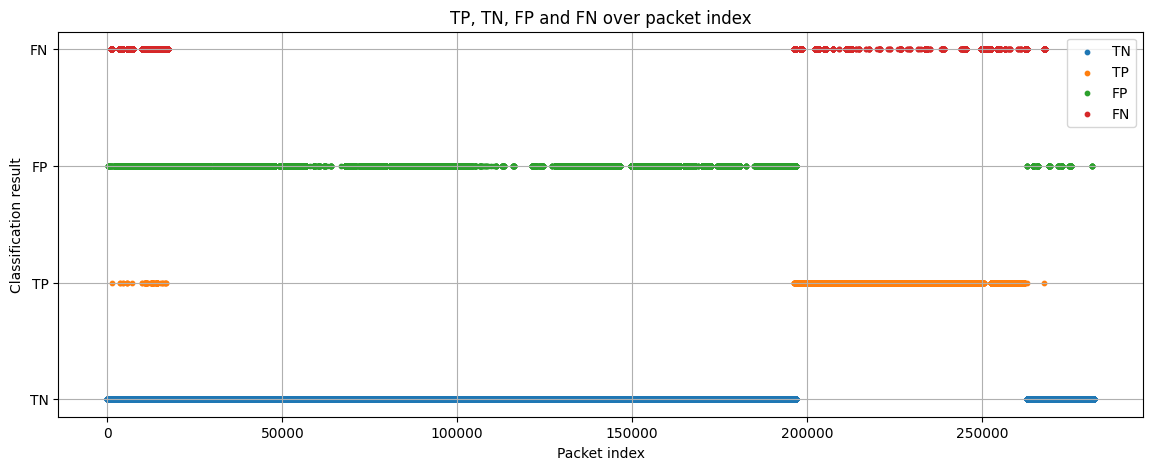

In [17]:
plt.figure(figsize=(14, 5))

classification_y = {
    "TN": 0,
    "TP": 1,
    "FP": 2,
    "FN": 3
}

results_df["plot_y"] = results_df["classification"].map(classification_y)

for label in ["TN", "TP", "FP", "FN"]:
    subset = results_df[results_df["classification"] == label]
    plt.scatter(
        subset["sequence_index"],
        subset["plot_y"],
        label=label,
        s=10
    )

plt.yticks(
    [0, 1, 2, 3],
    ["TN", "TP", "FP", "FN"]
)

plt.xlabel("Sequence index")
plt.ylabel("Classification result")
plt.title("TP, TN, FP and FN over sequence index")
plt.legend()
plt.grid(True)
plt.show()